# Dynamic Pricing under Capacity Constraints
### An Agent-Based Approach to Competition in the Car Rental Industry

**Master's Thesis (TFM) — Máster en Economics with Data Science, Universidad de Alicante**

This notebook implements the Agent-Based Model (ABM) described in the thesis: a synthetic oligopolistic car rental market in which firms compete on price under fleet capacity constraints, following one of four pricing rules (Average, Occupancy, Positional, Hybrid). The notebook is organized to mirror the structure of the written thesis, from model specification through the full experimental design, statistical testing, and robustness checks.

**Contents**
1. Setup and baseline parameters
2. Market initialization
3. Demand, logit allocation, and capacity rationing
4. Pricing rules
5. Simulation engine
6. Outcome metrics (RevPAR, occupancy stability)
7. Full experimental design (4 strategies × 4 scenarios × 20 seeds)
8. Calibration checks (β and D₀)
9. Results summary and visualization
10. Statistical testing (Welch, paired, Holm correction)
11. Sensitivity analysis: β sweep
12. Model diagram and internal verification tests


## 1. Setup and Baseline Parameters

All numerical parameters of the model are defined here as a single source of truth, matching the parameter table in the thesis (Section 3.4). Two parameters — `D0` and `BETA` — are the result of an explicit calibration process, checked further down in this notebook (Sections 8 and 8b); the values below are the final calibrated ones, not initial guesses.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Market and demand parameters (Section 3.2, Equations 6-8)
N = 10                  # number of firms
D0 = 161                # daily baseline demand (calibrated, see Section 8b)
BETA = 0.08             # price sensitivity in logit (calibrated, see Section 8)
SIGMA_D = 0.05          # relative Gaussian demand noise

# Seasonality scenarios (Section 3.6)
S_LOW = 1.0
S_HIGH = 1.6

# Rental duration and price adjustment (Section 3.3, Equation 9)
L = 4                   # average rental duration in days
LAMBDA = 0.03           # maximum daily price variation (3%)
P_MIN, P_MAX = 20.0, 120.0   # price bounds (€/day, synthetic)

# Pricing rule parameters (Section 3.4, Equations 10-13)
O_STAR = 0.85           # target occupancy (Occupancy rule)
GAMMA = 0.5             # weight of Occupancy rule in Hybrid rule

# Time horizon and replications
T = 180                 # simulated days per run
N_SEEDS = 20             # replications with different random seeds per combination

# Fleet capacity per firm (synthetic heterogeneity, Section 3.1)
K_RANGE = (80, 150)

STRATEGIES = ["average", "occupancy", "positional", "hybrid"]

## 2. Market Initialization

Generates each firm's fixed fleet capacity $K_i$ and initial price $p_{i,0}$. The `concentration` argument controls the fleet-size dispersion axis of the experimental design (Section 3.6): `"homogeneous"` markets have fleets of similar size across firms, while `"dispersed"` markets mix large and small operators, with capacities rescaled so that total market capacity is held constant across both cases — this keeps the comparison between the two scenarios clean.

In [2]:
def init_market(rng, concentration="homogeneous"):
    """
    Generates fleet capacities K_i and initial prices p_i,0
    for the N firms. 'concentration' controls the dispersion axis
    of fleet sizes (Section 3.6).
    """
    if concentration == "homogeneous":
        # similar fleets across firms, low dispersion
        K = rng.integers(110, 130, size=N).astype(float)
    elif concentration == "dispersed":
        # some large firms, some small; same aggregate capacity
        K = rng.integers(K_RANGE[0], K_RANGE[1] + 1, size=N).astype(float)
        K = K * (110 * N / K.sum())  # rescaled to match aggregate capacity
    else:
        raise ValueError("concentration must be 'homogeneous' or 'dispersed'")

    # initial prices: moderate dispersion around a reference price
    p0 = rng.uniform(45, 55, size=N)
    return K, p0

## 3. Aggregate Demand, Logit Allocation, and Capacity Rationing

Implements Equations (6)-(8) of the thesis: the stochastic aggregate demand process, the logit market-share model that allocates demand across firms by price, and the proportional rationing mechanism applied when demand exceeds a firm's available capacity (Section 3.2). Rationing runs in multiple passes because redistributing spillover demand to firms with slack capacity can, in turn, saturate those firms — the loop resolves this iteratively until no further redistribution is possible.

In [3]:
def aggregate_demand(rng, s_t):
    """Equation (6): D_t = D0 * s_t * (1 + eps_t)."""
    eps = rng.normal(0, SIGMA_D)
    return D0 * s_t * (1 + eps)

def logit_shares(prices, beta=BETA):
    """Equation (7): logit allocation of demand across firms."""
    x = -beta * prices
    x = x - x.max()  # numerical stability
    w = np.exp(x)
    return w / w.sum()

def ration_demand(desired_demand, K, O):
    """
    Equation (8) + proportional rationing (Section 3.2).
    desired_demand: array (N,) with d_{i,t} before capacity constraint.
    Returns b: array (N,) with effectively fulfilled demand.
    """
    available_capacity = K - O
    served = np.minimum(desired_demand, available_capacity)
    spillover = (desired_demand - served).sum()

    # proportional redistribution across firms with remaining available capacity
    for _ in range(N):  # multiple passes: unfulfilled spillover may re-saturate others
        residual_capacity = available_capacity - served
        if spillover <= 1e-9 or residual_capacity.sum() <= 1e-9:
            break
        eligible = residual_capacity > 1e-9
        weights = np.zeros(N)
        weights[eligible] = desired_demand[eligible] / desired_demand[eligible].sum()
        allocation = np.minimum(spillover * weights, residual_capacity)
        served += allocation
        spillover -= allocation.sum()

    return served

## 4. Pricing Rules

Implements Equations (10)-(13): the four pricing rules compared in this thesis. Each rule produces a bounded signal $\Delta_{i,t} \in [-1, 1]$ from a different subset of market information, but all four share the same adjustment mechanism (a maximum daily price change of $\lambda$), so that the strategies are directly comparable — they differ only in *what information* they react to, not in how aggressively they react to it.

- **Average** — reacts to the mean price of all rivals.
- **Occupancy** — reacts to the firm's own occupancy relative to a target.
- **Positional** — reacts to the mean price of the 3 rivals closest in price (the "Top-3").
- **Hybrid** — a weighted combination of Occupancy and Positional ($\gamma = 0.5$).

In [4]:
def delta_average(prices, i):
    """Equation (10)."""
    rivals = np.delete(prices, i)
    p_mean = rivals.mean()
    return (p_mean - prices[i]) / p_mean

def delta_occupancy(occupancies, i):
    """Equation (11)."""
    return (occupancies[i] - O_STAR) / O_STAR

def delta_positional(prices, i, k_neighbors=3):
    """Equation (12): mean of the k_neighbors rivals closest in price."""
    rival_indices = np.delete(np.arange(N), i)
    dist = np.abs(prices[rival_indices] - prices[i])
    top_indices = rival_indices[np.argsort(dist)[:k_neighbors]]
    p_top3 = prices[top_indices].mean()
    return (p_top3 - prices[i]) / p_top3

def delta_hybrid(prices, occupancies, i):
    """Equation (13)."""
    return GAMMA * delta_occupancy(occupancies, i) + (1 - GAMMA) * delta_positional(prices, i)

def compute_deltas(strategy, prices, occupancies):
    """Returns the array (N,) of delta_{i,t} signals for the specified strategy."""
    deltas = np.zeros(N)
    for i in range(N):
        if strategy == "average":
            deltas[i] = delta_average(prices, i)
        elif strategy == "occupancy":
            deltas[i] = delta_occupancy(occupancies, i)
        elif strategy == "positional":
            deltas[i] = delta_positional(prices, i)
        elif strategy == "hybrid":
            deltas[i] = delta_hybrid(prices, occupancies, i)
        else:
            raise ValueError(f"Unknown strategy: {strategy}")
    return deltas

def update_prices(prices, deltas):
    """Equation (9): bounded price adjustment."""
    updated = prices * (1 + LAMBDA * deltas)
    return np.clip(updated, P_MIN, P_MAX)

## 5. Simulation Engine

Runs a single market simulation of $T$ days under one strategy, one scenario, and one random seed. All $N$ firms apply the *same* pricing rule within a run — this is the **symmetric benchmarking** design described in Section 3.4 of the thesis: each run answers "what RevPAR would the market reach if every operator adopted this heuristic?", rather than modeling one firm deviating unilaterally from its rivals (that alternative question is left as future work, Section 6.6 of the thesis).

Note that `beta` is an explicit function argument (not only the global `BETA`), which is what lets the β-sweep robustness check in Section 11 vary price sensitivity without touching the rest of the model.

In [5]:
def simulate_market(strategy, s_t, concentration, seed, beta=BETA):
    """
    Simulates T days of a market where all N firms apply
    the same 'strategy', under the given scenario (s_t, concentration).
    Returns time series for occupancy, prices, and revenue.
    """
    rng = np.random.default_rng(seed)
    K, prices = init_market(rng, concentration)
    O = np.zeros(N)                                    # initial occupancy: empty market
    history_b = [np.zeros(N) for _ in range(L)]        # return queue

    occupancy_hist = np.zeros((T, N))
    revenue_hist = np.zeros((T, N))
    price_hist = np.zeros((T, N))

    for t in range(T):
        occupancies = O / K

        # 1. Price adjustment according to the rule
        if t > 0:  # day 0 uses initial prices
            deltas = compute_deltas(strategy, prices, occupancies)
            prices = update_prices(prices, deltas)

        # 2. Aggregate demand and logit allocation
        D_t = aggregate_demand(rng, s_t)
        shares = logit_shares(prices, beta)
        desired_demand = D_t * shares

        # 3. Capacity rationing
        b_t = ration_demand(desired_demand, K, O)

        # 4. Occupancy update (Equation 9): + bookings - returns
        returns = history_b.pop(0)
        O = np.clip(O + b_t - returns, 0, K)
        history_b.append(b_t)

        # Record metrics
        occupancy_hist[t] = O / K
        revenue_hist[t] = b_t * prices
        price_hist[t] = prices

    return {
        "occupancy": occupancy_hist,
        "revenue": revenue_hist,
        "price": price_hist,
        "K": K
    }

## 6. Outcome Metrics: RevPAR and Occupancy Stability

Two corrections are applied here relative to a naive reading of the simulation output, both documented explicitly in the thesis:

1. **Burn-in exclusion** — the market starts at zero occupancy ($O_{i,0}=0$), so the first `BURN_IN` days are a transient fleet fill-up period that would otherwise artificially inflate occupancy's temporal variance. These days are dropped from every metric.
2. **Revenue accounting (×L)** — each booking generates revenue over the full $L$-day rental duration, not only on the day it is made. RevPAR is therefore $\text{RevPAR} = \dfrac{\sum_t \sum_i b_{i,t}\, p_{i,t}\, L}{\sum_i K_i \cdot T_{\text{eff}}}$, i.e. revenue per available car-day.

In [6]:
BURN_IN = 20  # days discarded from metric calculation (methodological note, Section 3)

def compute_metrics(result):
    """
    RevPAR and occupancy stability, calculated excluding the
    first BURN_IN days of each simulation.

    CORRECTION: each booking b_t generates revenue across the L days
    of rental duration, not just on the booking day. Daily revenue
    for a booking cohort is therefore b_t * price * L,
    rather than b_t * price (Section 3.2, Equation 8 onward).
    """
    occupancy = result["occupancy"][BURN_IN:]
    revenue = result["revenue"][BURN_IN:] * L   # <-- core accounting adjustment
    K = result["K"]

    T_effective = occupancy.shape[0]
    total_revenue = revenue.sum()
    available_car_days = K.sum() * T_effective
    revpar = total_revenue / available_car_days

    stability = occupancy.std(axis=0).mean()
    mean_occ = occupancy.mean()

    return {
        "revpar": revpar,
        "occupancy_instability": stability,
        "mean_occupancy": mean_occ
    }

## 7. Full Experimental Design

Runs the complete 4 (strategies) × 4 (scenarios) × 20 (seeds) = 320 simulations that form the main results of the thesis (Section 3.6). The two experimental axes are:

- **Capacity tension**: low season ($s_t=1$, capacity slack) vs. high season ($s_t=1.6$, tight capacity).
- **Fleet size dispersion**: homogeneous fleets vs. dispersed fleets, with aggregate market capacity held constant across both.

Results are stored in `df_results`, one row per (strategy, scenario, seed).

In [7]:
scenarios = [
    ("low_homogeneous",  S_LOW,  "homogeneous"),
    ("low_dispersed",    S_LOW,  "dispersed"),
    ("high_homogeneous", S_HIGH, "homogeneous"),
    ("high_dispersed",   S_HIGH, "dispersed"),
]

rows = []
for strategy in STRATEGIES:
    for sc_name, s_t, concentration in scenarios:
        for seed in range(N_SEEDS):
            result = simulate_market(strategy, s_t, concentration, seed)
            metrics = compute_metrics(result)
            rows.append({
                "strategy": strategy,
                "scenario": sc_name,
                "seed": seed,
                **metrics,
            })

df_results = pd.DataFrame(rows)
df_results

,strategy,scenario,seed,revpar,occupancy_instability,mean_occupancy
0,average,low_homogeneous,0,28.151470,0.022582,0.553531
1,average,low_homogeneous,1,26.661867,0.015929,0.536630
2,average,low_homogeneous,2,26.757994,0.017167,0.546599
3,average,low_homogeneous,3,27.274815,0.017466,0.552642
4,average,low_homogeneous,4,26.791167,0.018732,0.523859
...,...,...,...,...,...,...
315,hybrid,high_dispersed,15,36.714960,0.057908,0.799450
316,hybrid,high_dispersed,16,36.292896,0.098646,0.799331
317,hybrid,high_dispersed,17,35.835673,0.060834,0.799229
318,hybrid,high_dispersed,18,36.978126,0.090283,0.798876


## 8. Calibration Checks: β and D₀

Two parameters — `BETA` (price sensitivity of demand) and `D0` (baseline daily demand) — were not chosen arbitrarily; both were calibrated against explicit, documented criteria before being fixed as constants in Section 1. These two cells reproduce that calibration reasoning and are not part of the model itself — they are a one-time sanity check.

**β**: a realistic price differential between competitors (10-15%) should produce a meaningfully higher market share for the cheaper firm, without that firm capturing the entire market.

**D₀**: baseline demand should be calibrated relative to total fleet capacity so that low season leaves genuine capacity slack (~55% occupancy) while high season tightens the market (~88%) without fully saturating it — this is what makes the "capacity tension" experimental axis produce meaningful variation between seasons.

In [8]:
# --- Beta calibration check ---
base_price = 50.0
differential = 0.125  # 12.5%
test_prices = np.array([base_price] + [base_price * (1 + differential)] * (N - 1))
test_shares = logit_shares(test_prices)
print(f"Market share of lowest-price firm (12.5% below): {test_shares[0]:.3f}")
print(f"Mean market share of remaining firms: {test_shares[1:].mean():.3f}")
# With BETA=0.08, a 12.5% differential should produce a distinctly higher share
# for the cheapest operator without capturing 100% of demand.

Market share of lowest-price firm (12.5% below): 0.155
Mean market share of remaining firms: 0.094


In [9]:
# --- D0 calibration check ---
rng_calib = np.random.default_rng(0)
K_calib, _ = init_market(rng_calib, "homogeneous")
target_occ_low = 0.55
D0_calibrated = target_occ_low * K_calib.sum() / (S_LOW * L)
print(f"Calibrated D0: {D0_calibrated:.1f}")
print(f"Natural occupancy (low season): {target_occ_low:.2f}")
print(f"Natural occupancy (high season): {D0_calibrated * S_HIGH * L / K_calib.sum():.2f}")

Calibrated D0: 160.9
Natural occupancy (low season): 0.55
Natural occupancy (high season): 0.88


## 9. Results Summary and Visualization

The main results table (mean RevPAR, its standard deviation across replications, and mean occupancy instability, by strategy and scenario) and its accompanying bar chart, corresponding to Table 1 and Figure 1 of the thesis results section. The two panels use independent y-axes, since RevPAR and instability live on very different numerical scales.

In [10]:
summary = df_results.groupby(["scenario", "strategy"]).agg(
    mean_revpar=("revpar", "mean"),
    std_revpar=("revpar", "std"),
    mean_instability=("occupancy_instability", "mean"),
).round(3)

summary

mean_revpar  std_revpar  mean_instability
scenario         strategy                                             
high_dispersed   average          40.144       0.666             0.079
                 hybrid           36.239       0.791             0.081
                 occupancy        32.551       0.550             0.079
                 positional       40.263       0.945             0.084
high_homogeneous average          40.103       0.651             0.046
                 hybrid           36.060       0.737             0.057
                 occupancy        32.325       0.517             0.055
                 positional       40.213       0.915             0.061
low_dispersed    average          29.364       0.481             0.022
                 hybrid           18.641       0.352             0.020
                 occupancy        14.265       0.164             0.040
                 positional       29.271       0.671             0.023
low_homogeneous  average          26.987       0.506             0.020
                 hybrid           15.924       0.453             0.018
                 occupancy        12.515       0.278             0.017
                 positional       26.869       0.676             0.019

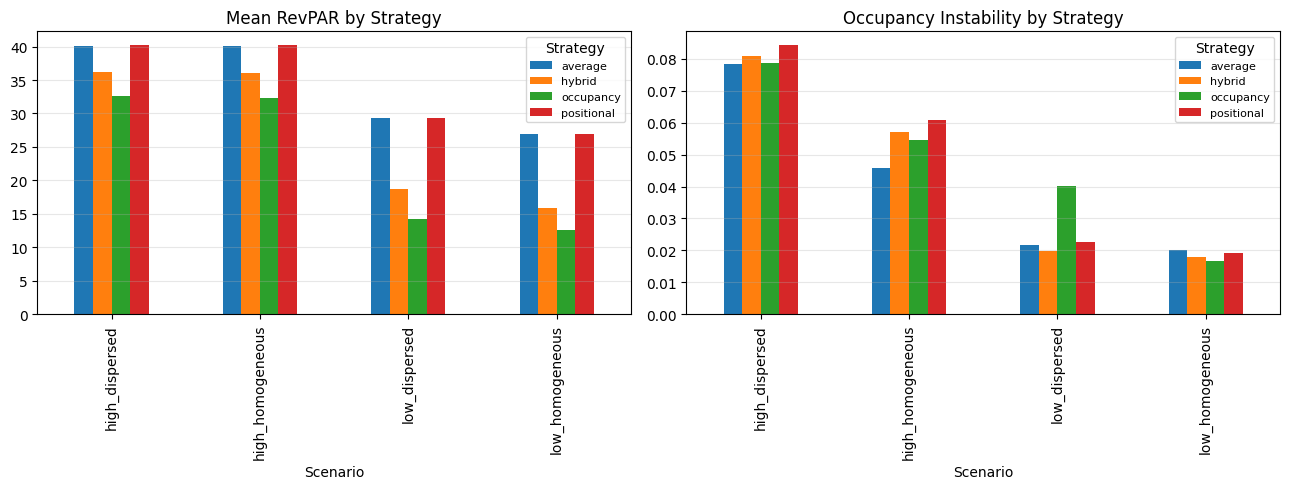

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, title in zip(
    axes, ["revpar", "occupancy_instability"],
    ["Mean RevPAR by Strategy", "Occupancy Instability by Strategy"]
):
    pivot = df_results.groupby(["scenario", "strategy"])[metric].mean().unstack()
    pivot.plot(kind="bar", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Scenario")
    ax.legend(title="Strategy", fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("results_chart.png", bbox_inches="tight", dpi=150)
plt.show()

## 10. Statistical Testing

Three layers of statistical rigor are applied to the results, in increasing order of power and robustness:

1. **Welch's t-test** (unequal variances) — an independent-samples comparison between any two strategies within a scenario. Used as a robustness check.
2. **Paired test by seed** — since every strategy is run under the *same* 20 seeds within a scenario (same fleet capacities, same initial prices, same demand noise), differencing by seed cancels that shared randomness and yields a more statistically powerful test. This is the **primary inferential specification** for RevPAR comparisons (Section 4.2 of the thesis).
3. **Holm correction** — applied to control the family-wise error rate across the 24 pairwise comparisons per metric, since running many tests at a nominal 5% threshold risks false positives.

In [12]:
from scipy import stats as st
from itertools import combinations

def welch_test(df, scenario, strategy_a, strategy_b, metric="revpar"):
    """
    Welch's t-test (unequal variances assumed) between two strategies
    within a given scenario on the specified metric.
    Returns t-statistic, p-value, and compared means.
    """
    a = df[(df.scenario == scenario) & (df.strategy == strategy_a)][metric]
    b = df[(df.scenario == scenario) & (df.strategy == strategy_b)][metric]
    t_stat, p_val = st.ttest_ind(a, b, equal_var=False)  # Welch's test
    return {
        "scenario": scenario,
        "comparison": f"{strategy_a} vs {strategy_b}",
        "mean_a": a.mean(),
        "mean_b": b.mean(),
        "t": t_stat,
        "p_value": p_val,
        "significant_5pct": p_val < 0.05,
    }

# All pairwise comparisons for each scenario on RevPAR
revpar_test_results = []
for scenario in df_results.scenario.unique():
    for strat_a, strat_b in combinations(STRATEGIES, 2):
        revpar_test_results.append(welch_test(df_results, scenario, strat_a, strat_b))

df_tests_revpar = pd.DataFrame(revpar_test_results).round(4)
df_tests_revpar

,scenario,comparison,mean_a,mean_b,t,p_value,significant_5pct
0,low_homogeneous,average vs occupancy,26.9874,12.5152,112.2240,0.0000,True
1,low_homogeneous,average vs positional,26.9874,26.8691,0.6265,0.5350,False
2,low_homogeneous,average vs hybrid,26.9874,15.9245,72.8841,0.0000,True
3,low_homogeneous,occupancy vs positional,12.5152,26.8691,-87.8260,0.0000,True
4,low_homogeneous,occupancy vs hybrid,12.5152,15.9245,-28.7013,0.0000,True
5,low_homogeneous,positional vs hybrid,26.8691,15.9245,60.1384,0.0000,True
6,low_dispersed,average vs occupancy,29.3639,14.2648,132.7815,0.0000,True
7,low_dispersed,average vs positional,29.3639,29.2712,0.5020,0.6189,False
8,low_dispersed,average vs hybrid,29.3639,18.6412,80.4274,0.0000,True
9,low_dispersed,occupancy vs positional,14.2648,29.2712,-97.1002,0.0000,True


### Welch's test — occupancy instability

In [13]:
instability_test_results = []
for scenario in df_results.scenario.unique():
    for strat_a, strat_b in combinations(STRATEGIES, 2):
        instability_test_results.append(
            welch_test(df_results, scenario, strat_a, strat_b, metric="occupancy_instability")
        )

df_tests_instability = pd.DataFrame(instability_test_results).round(4)
df_tests_instability

,scenario,comparison,mean_a,mean_b,t,p_value,significant_5pct
0,low_homogeneous,average vs occupancy,0.0200,0.0166,4.6027,0.0001,True
1,low_homogeneous,average vs positional,0.0200,0.0192,0.6897,0.4949,False
2,low_homogeneous,average vs hybrid,0.0200,0.0178,2.6615,0.0117,True
3,low_homogeneous,occupancy vs positional,0.0166,0.0192,-2.8232,0.0093,True
4,low_homogeneous,occupancy vs hybrid,0.0166,0.0178,-2.0802,0.0451,True
5,low_homogeneous,positional vs hybrid,0.0192,0.0178,1.4183,0.1665,False
6,low_dispersed,average vs occupancy,0.0217,0.0401,-14.0292,0.0000,True
7,low_dispersed,average vs positional,0.0217,0.0227,-0.8634,0.3940,False
8,low_dispersed,average vs hybrid,0.0217,0.0199,2.0870,0.0436,True
9,low_dispersed,occupancy vs positional,0.0401,0.0227,11.8215,0.0000,True


### Paired test by seed (primary specification for RevPAR)

In [14]:
def paired_test(df, scenario, strategy_a, strategy_b, metric="revpar"):
    """
    Paired test: computes difference metric_a - metric_b across seeds
    (same seed = same exogenous market conditions), then runs a 1-sample
    t-test against the null hypothesis of zero mean difference.
    """
    a = df[(df.scenario == scenario) & (df.strategy == strategy_a)] \
            .sort_values("seed")[metric].values
    b = df[(df.scenario == scenario) & (df.strategy == strategy_b)] \
            .sort_values("seed")[metric].values

    diffs = a - b
    t_stat, p_val = st.ttest_1samp(diffs, popmean=0)

    # 95% confidence interval of mean difference
    n = len(diffs)
    se = diffs.std(ddof=1) / np.sqrt(n)
    ci_low, ci_high = st.t.interval(0.95, df=n-1, loc=diffs.mean(), scale=se)

    return {
        "scenario": scenario,
        "comparison": f"{strategy_a} vs {strategy_b}",
        "mean_difference": diffs.mean(),
        "ci_95_low": ci_low,
        "ci_95_high": ci_high,
        "t_paired": t_stat,
        "p_value_paired": p_val,
    }

paired_results = []
for scenario in df_results.scenario.unique():
    for strat_a, strat_b in combinations(STRATEGIES, 2):
        paired_results.append(paired_test(df_results, scenario, strat_a, strat_b))

df_tests_paired = pd.DataFrame(paired_results).round(4)
df_tests_paired

,scenario,comparison,mean_difference,ci_95_low,ci_95_high,t_paired,p_value_paired
0,low_homogeneous,average vs occupancy,14.4722,14.3206,14.6237,199.8508,0.0000
1,low_homogeneous,average vs positional,0.1183,-0.0106,0.2472,1.9202,0.0700
2,low_homogeneous,average vs hybrid,11.0629,10.9758,11.1499,265.9452,0.0000
3,low_homogeneous,occupancy vs positional,-14.3539,-14.5966,-14.1112,-123.7826,0.0000
4,low_homogeneous,occupancy vs hybrid,-3.4093,-3.5030,-3.3156,-76.1352,0.0000
5,low_homogeneous,positional vs hybrid,10.9446,10.7711,11.1180,132.0713,0.0000
6,low_dispersed,average vs occupancy,15.0992,14.9344,15.2639,191.7948,0.0000
7,low_dispersed,average vs positional,0.0927,-0.0415,0.2270,1.4458,0.1645
8,low_dispersed,average vs hybrid,10.7228,10.6237,10.8218,226.5135,0.0000
9,low_dispersed,occupancy vs positional,-15.0064,-15.2616,-14.7513,-123.1151,0.0000


### Holm correction for multiple comparisons

In [15]:
from statsmodels.stats.multitest import multipletests

def apply_holm(df_tests, col_p="p_value"):
    """Applies Holm step-down procedure to control family-wise error rate."""
    reject, p_adjusted, _, _ = multipletests(df_tests[col_p], alpha=0.05, method="holm")
    df_out = df_tests.copy()
    df_out["p_holm"] = p_adjusted.round(4)
    df_out["sig_holm_5pct"] = reject
    return df_out

# Applied to paired RevPAR tests
df_revpar_paired_holm = apply_holm(df_tests_paired, col_p="p_value_paired")
df_revpar_paired_holm

,scenario,comparison,mean_difference,ci_95_low,ci_95_high,t_paired,p_value_paired,p_holm,sig_holm_5pct
0,low_homogeneous,average vs occupancy,14.4722,14.3206,14.6237,199.8508,0.0000,0.0000,True
1,low_homogeneous,average vs positional,0.1183,-0.0106,0.2472,1.9202,0.0700,0.2800,False
2,low_homogeneous,average vs hybrid,11.0629,10.9758,11.1499,265.9452,0.0000,0.0000,True
3,low_homogeneous,occupancy vs positional,-14.3539,-14.5966,-14.1112,-123.7826,0.0000,0.0000,True
4,low_homogeneous,occupancy vs hybrid,-3.4093,-3.5030,-3.3156,-76.1352,0.0000,0.0000,True
5,low_homogeneous,positional vs hybrid,10.9446,10.7711,11.1180,132.0713,0.0000,0.0000,True
6,low_dispersed,average vs occupancy,15.0992,14.9344,15.2639,191.7948,0.0000,0.0000,True
7,low_dispersed,average vs positional,0.0927,-0.0415,0.2270,1.4458,0.1645,0.4935,False
8,low_dispersed,average vs hybrid,10.7228,10.6237,10.8218,226.5135,0.0000,0.0000,True
9,low_dispersed,occupancy vs positional,-15.0064,-15.2616,-14.7513,-123.1151,0.0000,0.0000,True


In [16]:
# Applied to occupancy instability tests (independent Welch)
df_instability_holm = apply_holm(df_tests_instability, col_p="p_value")
df_instability_holm

,scenario,comparison,mean_a,mean_b,t,p_value,significant_5pct,p_holm,sig_holm_5pct
0,low_homogeneous,average vs occupancy,0.0200,0.0166,4.6027,0.0001,True,0.0021,True
1,low_homogeneous,average vs positional,0.0200,0.0192,0.6897,0.4949,False,1.0000,False
2,low_homogeneous,average vs hybrid,0.0200,0.0178,2.6615,0.0117,True,0.2106,False
3,low_homogeneous,occupancy vs positional,0.0166,0.0192,-2.8232,0.0093,True,0.1767,False
4,low_homogeneous,occupancy vs hybrid,0.0166,0.0178,-2.0802,0.0451,True,0.6540,False
5,low_homogeneous,positional vs hybrid,0.0192,0.0178,1.4183,0.1665,False,1.0000,False
6,low_dispersed,average vs occupancy,0.0217,0.0401,-14.0292,0.0000,True,0.0000,True
7,low_dispersed,average vs positional,0.0217,0.0227,-0.8634,0.3940,False,1.0000,False
8,low_dispersed,average vs hybrid,0.0217,0.0199,2.0870,0.0436,True,0.6540,False
9,low_dispersed,occupancy vs positional,0.0401,0.0227,11.8215,0.0000,True,0.0000,True


## 11. Sensitivity Analysis: β Sweep

A preliminary, non-controlled comparison of two model calibrations suggested that the Positional strategy's advantage over Average might grow with demand's price sensitivity ($\beta$). That comparison, however, changed $\beta$, $N$ and $D_0$ simultaneously, so it could not isolate $\beta$'s effect. This section runs a **controlled sweep**: only $\beta$ varies across seven values, with $N$, $D_0$, and all four scenarios held fixed, replicated over 20 seeds each — directly testing whether that preliminary conjecture holds.

In [17]:
betas = [0.04, 0.08, 0.12, 0.20, 0.30, 0.35, 0.50]

rows_beta = []
for beta in betas:
    for sc_name, s_t, concentration in scenarios:
        for seed in range(N_SEEDS):
            rp_avg = compute_metrics(
                simulate_market("average", s_t, concentration, seed, beta=beta)
            )["revpar"]
            rp_pos = compute_metrics(
                simulate_market("positional", s_t, concentration, seed, beta=beta)
            )["revpar"]
            rows_beta.append({
                "beta": beta,
                "scenario": sc_name,
                "seed": seed,
                "revpar_average": rp_avg,
                "revpar_positional": rp_pos,
                "positional_advantage": rp_pos - rp_avg,
            })

df_beta = pd.DataFrame(rows_beta)

# Summary: mean advantage +- 95% CI aggregating all 4 scenarios per beta
summary_beta = df_beta.groupby("beta").agg(
    mean_advantage=("positional_advantage", "mean"),
    std_advantage=("positional_advantage", "std"),
    n=("positional_advantage", "count"),
)
summary_beta["se"] = summary_beta["std_advantage"] / np.sqrt(summary_beta["n"])
summary_beta["ci_low"] = summary_beta["mean_advantage"] - 1.96 * summary_beta["se"]
summary_beta["ci_high"] = summary_beta["mean_advantage"] + 1.96 * summary_beta["se"]

pvals = []
for beta in betas:
    sub = df_beta[df_beta.beta == beta]["positional_advantage"]
    _, p = st.ttest_1samp(sub, popmean=0)
    pvals.append(p)
summary_beta["p_value"] = pvals

summary_beta.round(4)

,mean_advantage,std_advantage,n,se,ci_low,ci_high,p_value
beta,,,,,,,
0.04,0.0475,0.3364,80,0.0376,-0.0262,0.1212,0.2104
0.08,0.0045,0.3554,80,0.0397,-0.0734,0.0823,0.9109
0.12,-0.0265,0.3756,80,0.0420,-0.1088,0.0559,0.5306
0.20,-0.0591,0.3992,80,0.0446,-0.1466,0.0284,0.1892
0.30,-0.0783,0.4147,80,0.0464,-0.1692,0.0126,0.0951
0.35,-0.0827,0.4177,80,0.0467,-0.1742,0.0088,0.0804
0.50,-0.0896,0.4219,80,0.0472,-0.1821,0.0028,0.0610


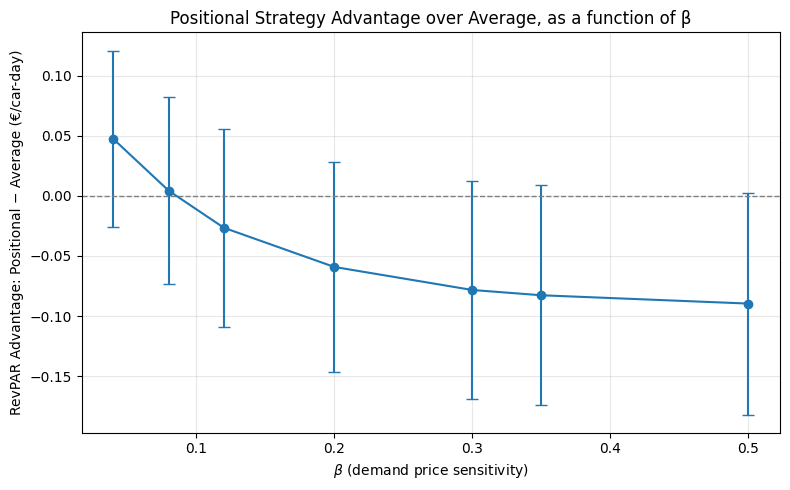

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(summary_beta.index, summary_beta["mean_advantage"],
            yerr=1.96*summary_beta["se"], marker="o", capsize=4)
ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel(r"$\beta$ (demand price sensitivity)")
ax.set_ylabel("RevPAR Advantage: Positional − Average (€/car-day)")
ax.set_title("Positional Strategy Advantage over Average, as a function of β")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("beta_sweep.png", bbox_inches="tight", dpi=150)
plt.show()

## 12. Model Flowchart

A single-generation diagram of the daily event sequence (Section 3.1 of the thesis), rendered once and exported for inclusion in the written report — it is not part of the simulation logic itself.

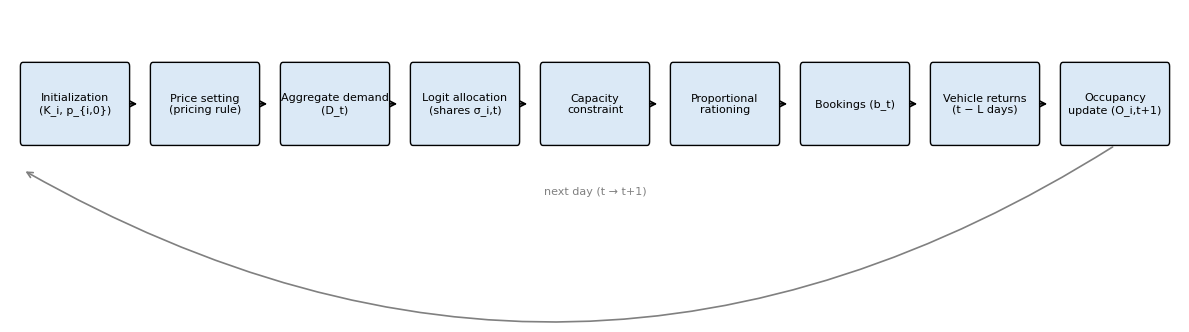

In [19]:
import matplotlib.patches as mpatches

steps = [
    "Initialization\n(K_i, p_{i,0})",
    "Price setting\n(pricing rule)",
    "Aggregate demand\n(D_t)",
    "Logit allocation\n(shares σ_i,t)",
    "Capacity\nconstraint",
    "Proportional\nrationing",
    "Bookings (b_t)",
    "Vehicle returns\n(t − L days)",
    "Occupancy\nupdate (O_i,t+1)",
]

fig, ax = plt.subplots(figsize=(12, 3))
n_steps = len(steps)
xs = np.linspace(0.5, n_steps - 0.5, n_steps)
for x, text in zip(xs, steps):
    ax.add_patch(mpatches.FancyBboxPatch((x - 0.4, 0.3), 0.8, 0.4,
                                         boxstyle="round,pad=0.02", edgecolor="black", facecolor="#dbe9f6"))
    ax.text(x, 0.5, text, ha="center", va="center", fontsize=8)
    if x < xs[-1]:
        ax.annotate("", xy=(x + 0.5, 0.5), xytext=(x + 0.4, 0.5),
                    arrowprops=dict(arrowstyle="->", lw=1.2))

# Return loop arrow (next day transition)
ax.annotate("", xy=(0.1, 0.15), xytext=(xs[-1], 0.28),
            arrowprops=dict(arrowstyle="->", lw=1.2,
                            connectionstyle="arc3,rad=-0.3", color="gray"))
ax.text(n_steps / 2, 0.02, "next day (t → t+1)", ha="center", fontsize=8, color="gray")

ax.set_xlim(0, n_steps)
ax.set_ylim(0, 1)
ax.axis("off")
plt.tight_layout()
plt.savefig("model_diagram.png", bbox_inches="tight", dpi=150)
plt.show()

## 13. Internal Verification Tests

Since the model's calibration cannot be validated against real external data (Section 3.5, Limitations), this final section runs six consistency checks confirming that the simulator's components behave as the underlying logit and rationing equations analytically predict. These are not part of the experimental design — they are a one-time correctness check on the implementation.

In [20]:
print("Test 1: identical prices → uniform shares equal to 1/N")
equal_prices = np.full(N, 50.0)
shares = logit_shares(equal_prices)
assert np.allclose(shares, 1/N, atol=1e-9), "FAIL: shares not uniform with equal prices"
print(f"  OK: per-firm share = {shares[0]:.4f} (expected {1/N:.4f})\n")

print("Test 2: increasing firm price reduces its market share")
test_prices = np.full(N, 50.0)
share_before = logit_shares(test_prices)[0]
test_prices[0] = 60.0
share_after = logit_shares(test_prices)[0]
assert share_after < share_before, "FAIL: share did not decrease after price increase"
print(f"  OK: share decreased from {share_before:.4f} to {share_after:.4f}\n")

print("Test 3: β → 0 implies shares → 1/N (price-inelastic demand)")
dispersed_prices = np.array([40, 45, 50, 55, 60, 65, 70, 75, 80, 85], dtype=float)
shares_low_beta = logit_shares(dispersed_prices, beta=1e-6)
assert np.allclose(shares_low_beta, 1/N, atol=1e-3), "FAIL: β→0 does not converge to uniform distribution"
print(f"  OK: with β≈0, standard deviation of shares = {shares_low_beta.std():.6f} (≈0)\n")

print("Test 4: higher β amplifies share spread for identical price dispersion")
shares_beta_low = logit_shares(dispersed_prices, beta=0.02)
shares_beta_high = logit_shares(dispersed_prices, beta=0.20)
range_low = shares_beta_low.max() - shares_beta_low.min()
range_high = shares_beta_high.max() - shares_beta_high.min()
assert range_high > range_low, "FAIL: higher β does not increase share dispersion"
print(f"  OK: share range with β=0.02: {range_low:.3f}; with β=0.20: {range_high:.3f}\n")

print("Test 5: demand well below capacity → no rationing")
K_test = np.full(N, 120.0)
O_test = np.zeros(N)
low_demand = np.full(N, 5.0)  # far below capacity K_i
served = ration_demand(low_demand, K_test, O_test)
assert np.allclose(served, low_demand), "FAIL: unnecessary rationing triggered"
print(f"  OK: served demand = desired demand when capacity slack exists\n")

print("Test 6: demand far exceeding aggregate capacity → occupancy → 100%")
excess_demand = np.full(N, 200.0)  # far above total capacity
served_excess = ration_demand(excess_demand, K_test, O_test)
assert np.allclose(served_excess, K_test, atol=1.0), "FAIL: capacity not fully saturated"
print(f"  OK: resulting occupancy ≈ 100% under severe excess demand\n")

print("All internal verification tests passed successfully.")

Test 1: identical prices → uniform shares equal to 1/N
  OK: per-firm share = 0.1000 (expected 0.1000)

Test 2: increasing firm price reduces its market share
  OK: share decreased from 0.1000 to 0.0476

Test 3: β → 0 implies shares → 1/N (price-inelastic demand)
  OK: with β≈0, standard deviation of shares = 0.000001 (≈0)

Test 4: higher β amplifies share spread for identical price dispersion
  OK: share range with β=0.02: 0.089; with β=0.20: 0.632

Test 5: demand well below capacity → no rationing
  OK: served demand = desired demand when capacity slack exists

Test 6: demand far exceeding aggregate capacity → occupancy → 100%
  OK: resulting occupancy ≈ 100% under severe excess demand

All internal verification tests passed successfully.
